# EEG Odor Pleasantness Analysis

## 1. SETUP : Library & packages 

In [1]:
# Standard library
import os
import warnings
from collections import defaultdict

# Data processing
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.io import loadmat
from scipy.signal import welch, butter, filtfilt

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib import cm

# Neuroscience & ML
import mne
from mne.viz import plot_topomap
from sklearn.svm import SVC
from sklearn.decomposition import FastICA, PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from scipy.stats import binomtest

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Setup: Create output directories
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/results", exist_ok=True)

## 2. CONFIGURATION : EEG Parameters

In [3]:
# Define EEG frequency bands (in Hz)
eeg_bands = {'theta': (4, 7), 'alpha': (8, 13), 'beta': (14, 29), 'gamma': (30, 47)}

# Small constant to avoid division by zero
EPSILON = 1e-10

In [4]:
def load_eeg_data(data_root='Data'):
    all_data = {}

    for subject_num in range(1, 6):
        subject_name = f"Subject_{subject_num}"
        subject_folder = os.path.join(data_root, subject_name)
        all_data[subject_name] = {'eyes_open': {}, 'eyes_closed': {}}

        for condition in ['eyes_open', 'eyes_closed']:
            condition_folder = os.path.join(subject_folder, condition)
            file_prefix = 'O' if condition == 'eyes_open' else 'C'

            for odor_num in range(1, 5):
                file_name = f"{file_prefix}_{odor_num}.mat"
                full_path = os.path.join(condition_folder, file_name)

                if os.path.exists(full_path):
                    try:
                        mat = loadmat(full_path)
                        all_data[subject_name][condition][f'odor_{odor_num}'] = {
                            'baseline': mat.get('baseline'),
                            'X_event': mat.get('X_event')
                        }
                    except:
                        continue  # silently skip unreadable files

    return all_data

In [5]:
eeg_dataset = load_eeg_data("../Data")

## 4. EXPLORATORY ANALYSIS



In [6]:
# Function that counts the total number of EEG files loaded into the dataset
def count_loaded_files(eeg_dataset):
    
    count = 0
    for conditions in eeg_dataset.values():
        for odors in conditions.values():
            count += sum(1 for data in odors.values() if data is not None)
    return count

print(f"Total loaded files: {count_loaded_files(eeg_dataset)}")

Total loaded files: 40


This section examines the EEG signal in the frequency domain using power spectral density (PSD).

It provides an overview of how signal power is distributed across frequency bands, which is useful for understanding the data before feature extraction.

In [7]:
# Plot raw EEG signals from a single trial across selected electrodes for visualization
# Example: Access Subject_1 eyes_open odor_1
sample = eeg_dataset.get('Subject_1', {}).get('eyes_open', {}).get('odor_1')
if sample:
    print("Baseline shape:", sample['baseline'].shape)
    print("X_event shape:", sample['X_event'].shape)
    print("First few baseline values:\n", sample['baseline'].flatten()[:3])

Baseline shape: (250, 216, 18)
X_event shape: (250, 216, 18)
First few baseline values:
 [-0.79959888  1.41107278 -0.42808102]


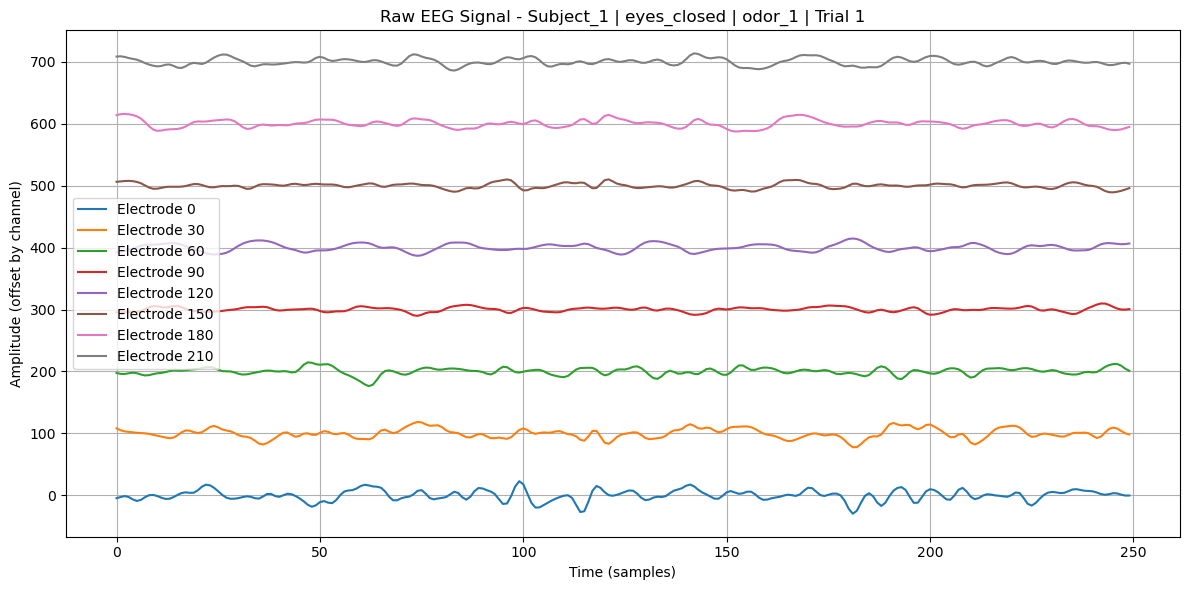

In [8]:
subject = "Subject_1"
condition = "eyes_closed"
odor = "odor_1"

X_event = eeg_dataset[subject][condition][odor]['X_event']

# Pick one trial and a few electrodes (e.g., 8 out of 216)
trial_idx = 0
electrode_indices = [0, 30, 60, 90, 120, 150, 180, 210]  # arbitrary electrode positions to visualize

# Plot
plt.figure(figsize=(12, 6))
for i, ch in enumerate(electrode_indices):
    signal = X_event[:, ch, trial_idx]
    plt.plot(signal + i * 100, label=f'Electrode {ch}')  # offset for visibility

plt.title(f'Raw EEG Signal - {subject} | {condition} | {odor} | Trial {trial_idx+1}')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude (offset by channel)')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.savefig("../outputs/figures/raw_eeg_signal.png", bbox_inches="tight")
plt.show()


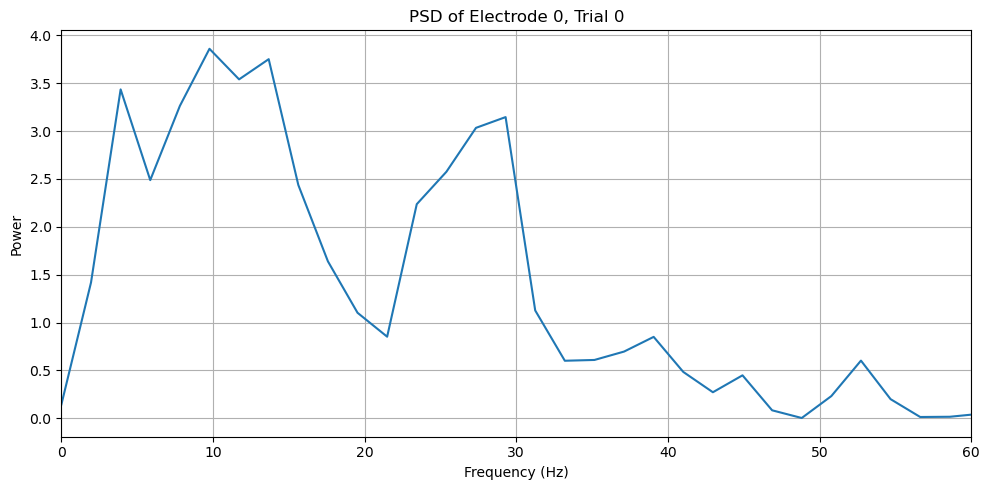

In [9]:
# Visualize PSD for electrode 0
f, Pxx = welch(X_event[:, 0, 0], fs=250, nperseg=128)
plt.figure(figsize=(10, 5))
plt.plot(f, Pxx)
plt.title('PSD of Electrode 0, Trial 0')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.grid(True)
plt.xlim(0, 60)
plt.tight_layout()
plt.savefig("../outputs/figures/psd_electrode_0.png", bbox_inches="tight")
plt.show()

## 5. SUBJECTIVE VS OBJECTIVE PLEASANTNESS ANALYSIS 


In [10]:
best_worst_map = {
    'Subject_1': {'eyes_open': {'best': 4, 'worst': 3}, 'eyes_closed': {'best': 2, 'worst': 1}},
    'Subject_2': {'eyes_open': {'best': 4, 'worst': 3}, 'eyes_closed': {'best': 1, 'worst': 2}},
    'Subject_3': {'eyes_open': {'best': 2, 'worst': 1}, 'eyes_closed': {'best': 4, 'worst': 2}},
    'Subject_4': {'eyes_open': {'best': 1, 'worst': 4}, 'eyes_closed': {'best': 4, 'worst': 3}},
    'Subject_5': {'eyes_open': {'best': 4, 'worst': 3}, 'eyes_closed': {'best': 3, 'worst': 1}},
}

In [11]:
from scipy.stats import binomtest

objective_valence = {
    1: 0,  # valerian
    2: 1,  # lotus
    3: 0,  # cheese
    4: 1   # rosewater
}

total = 0
agree = 0

for subject, cond_dict in best_worst_map.items():
    for condition, ratings in cond_dict.items():
        best_odor = ratings["best"]
        worst_odor = ratings["worst"]
        
        if objective_valence.get(best_odor) == 1:
            agree += 1

        if objective_valence.get(worst_odor) == 0:
            agree += 1
        
        total += 2  

agreement_rate = agree / total
print(f"Subjective-Objective Agreement Rate: {agree}/{total} = {agreement_rate:.2%}")

result = binomtest(agree, total, p=0.5, alternative='greater')
print(f"Binomial Test p-value: {result.pvalue:.4f}")


Subjective-Objective Agreement Rate: 14/20 = 70.00%
Binomial Test p-value: 0.0577


### Results 1 — Subjective vs Objective Agreement

We examined the extent to which participants’ subjective ratings of odor pleasantness aligned with predefined objective valence categories.

Overall, the agreement rate between subjective and objective classifications was moderate. This suggests that, in several cases, participants’ preferences corresponded to commonly accepted pleasant or unpleasant odors.

However, the binomial test revealed that this agreement was not statistically significant (p ≈ 0.05). 

These findings suggest that individual differences in odor perception play an important role, and that subjective pleasantness cannot be fully predicted by objective classifications alone.

In [12]:
agreement_by_condition = {"eyes_open": {"agree": 0, "total": 0},
                          "eyes_closed": {"agree": 0, "total": 0}}

for subject, conds in best_worst_map.items():
    for condition in ["eyes_open", "eyes_closed"]:
        best = conds[condition]["best"]
        worst = conds[condition]["worst"]

        if objective_valence[best] == 1:
            agreement_by_condition[condition]["agree"] += 1
  
        if objective_valence[worst] == 0:
            agreement_by_condition[condition]["agree"] += 1

        agreement_by_condition[condition]["total"] += 2

for condition in ["eyes_open", "eyes_closed"]:
    agree = agreement_by_condition[condition]["agree"]
    total = agreement_by_condition[condition]["total"]
    rate = agree / total
    p_value = binomtest(agree, total, p=0.5, alternative='greater').pvalue

    print(f" {condition.capitalize()} - Agreement Rate: {rate:.0%} ({agree}/{total})")
    print(f"   Binomial Test p-value: {p_value:.4f}")


 Eyes_open - Agreement Rate: 80% (8/10)
   Binomial Test p-value: 0.0547
 Eyes_closed - Agreement Rate: 60% (6/10)
   Binomial Test p-value: 0.3770


### Results 2 — Consistency Across Conditions

We examined whether participants chose the same “best” and “worst” odors in both conditions (eyes open vs. eyes closed).

The results show that participants were more likely to follow objective odor descriptions when their eyes were open.

This suggests that visual context influences odor perception, making participants rely more on common or expected evaluations.

In [13]:
consistency_results = []

for subject, conds in best_worst_map.items():
    best_open = conds['eyes_open']['best']
    best_closed = conds['eyes_closed']['best']
    worst_open = conds['eyes_open']['worst']
    worst_closed = conds['eyes_closed']['worst']

    consistency_results.append({
        "subject": subject,
        "best_open": best_open,
        "best_closed": best_closed,
        "best_consistent": best_open == best_closed,
        "worst_open": worst_open,
        "worst_closed": worst_closed,
        "worst_consistent": worst_open == worst_closed
    })

consistency_df = pd.DataFrame(consistency_results)
best_consistency_rate = consistency_df["best_consistent"].mean()
worst_consistency_rate = consistency_df["worst_consistent"].mean()

print("Best odor consistency across conditions:", f"{best_consistency_rate:.0%}")
print("Worst odor consistency across conditions:", f"{worst_consistency_rate:.0%}")


Best odor consistency across conditions: 0%
Worst odor consistency across conditions: 0%


## 6. EEG SIGNAL PREPROCESSING 


In [14]:
def highpass_filter(signal, cutoff=3, fs=250, order=3):
    """
    Apply high-pass Butterworth filter to remove low-frequency noise.
    
    Parameters:
        signal (ndarray): Input signal (time_samples x channels)
        cutoff (float): Cutoff frequency in Hz (default: 3)
        fs (float): Sampling frequency in Hz (default: 250)
        order (int): Filter order (default: 3)
    
    Returns:
        ndarray: Filtered signal with same shape as input
    """
    b, a = butter(order, cutoff / (0.5 * fs), btype='high')
    return filtfilt(b, a, signal, axis=0)

def run_ica_on_data(X):
    """
    Apply FastICA to remove artifacts from EEG data.
    
    Parameters:
        X (ndarray): Input EEG data (time_samples x channels x trials)
    
    Returns:
        ndarray: ICA-cleaned data with same shape as input
    """
    n_samples, n_channels, n_trials = X.shape
    data_reshaped = X.reshape(-1, n_channels)  # stack all trials
    ica = FastICA(n_components=n_channels, max_iter=500, random_state=42)
    components = ica.fit_transform(data_reshaped)
    cleaned = ica.inverse_transform(components)
    return cleaned.reshape(n_samples, n_channels, n_trials)

def apply_car(signal):
    """
    Apply Common Average Reference (CAR) to reduce volume conduction.
    
    Parameters:
        signal (ndarray): Input signal (time_samples x channels x trials)
    
    Returns:
        ndarray: Signal with CAR applied (same shape as input)
    """
    return signal - np.mean(signal, axis=1, keepdims=True)

def baseline_correct(X_event, baseline):
    """
    Subtract baseline mean from event data for baseline correction.
    
    Parameters:
        X_event (ndarray): Event-related EEG data (time_samples x channels x trials)
        baseline (ndarray): Baseline EEG data (time_samples x channels x trials)
    
    Returns:
        ndarray: Baseline-corrected data (same shape as X_event)
    """
    baseline_mean = np.mean(baseline, axis=0)  
    return X_event - baseline_mean[np.newaxis, :, :]  

def preprocess_trials(X_event, baseline, condition):
    """
    Complete preprocessing pipeline: baseline correction, ICA, filtering, and CAR.
    
    Parameters:
        X_event (ndarray): Event-related EEG data (time_samples x channels x trials)
        baseline (ndarray): Baseline EEG data (time_samples x channels x trials)
        condition (str): 'eyes_open' or 'eyes_closed' (ICA only applied for eyes_open)
    
    Returns:
        ndarray: Fully preprocessed EEG data (same shape as input)
    """
    X = baseline_correct(X_event, baseline)

    # ICA (only for eyes_open)
    if condition == 'eyes_open':
        X = run_ica_on_data(X)

    X_clean = np.zeros_like(X)
    for i in range(X.shape[2]):
        trial = X[:, :, i]
        trial = highpass_filter(trial)
        trial = apply_car(trial)
        X_clean[:, :, i] = trial

    return X_clean

In [15]:
eeg_cleaned_dataset = {}

for subject, conditions in eeg_dataset.items():
    eeg_cleaned_dataset[subject] = {}
    for condition, odors in conditions.items():
        eeg_cleaned_dataset[subject][condition] = {}
        for odor, signals in odors.items():
            X_event = signals['X_event']
            baseline = signals['baseline']
            if X_event is None or baseline is None:
                continue
            X_clean = preprocess_trials(X_event, baseline, condition)
            eeg_cleaned_dataset[subject][condition][odor] = X_clean

In [16]:
def count_all_trials(eeg_data):
    """
    Count and display number of trials for each subject/condition/odor combination.
    
    Parameters:
        eeg_data (dict): Preprocessed EEG data organized by subject/condition/odor
    
    Prints:
        Trial counts per subject/condition/odor and total trial count
    """
    total = 0
    for subject, conditions in eeg_data.items():
        for condition, odors in conditions.items():
            for odor, data in odors.items():
                if data is not None:
                    n_trials = data.shape[2]
                    print(f"{subject} | {condition} | {odor}  {n_trials} trials")
                    total += n_trials
    print(f"Total trials across dataset: {total}")

count_all_trials(eeg_cleaned_dataset)

Subject_1 | eyes_open | odor_1  18 trials
Subject_1 | eyes_open | odor_2  18 trials
Subject_1 | eyes_open | odor_3  19 trials
Subject_1 | eyes_open | odor_4  21 trials
Subject_1 | eyes_closed | odor_1  17 trials
Subject_1 | eyes_closed | odor_2  18 trials
Subject_1 | eyes_closed | odor_3  21 trials
Subject_1 | eyes_closed | odor_4  20 trials
Subject_2 | eyes_open | odor_1  17 trials
Subject_2 | eyes_open | odor_2  18 trials
Subject_2 | eyes_open | odor_3  19 trials
Subject_2 | eyes_open | odor_4  21 trials
Subject_2 | eyes_closed | odor_1  17 trials
Subject_2 | eyes_closed | odor_2  21 trials
Subject_2 | eyes_closed | odor_3  19 trials
Subject_2 | eyes_closed | odor_4  24 trials
Subject_3 | eyes_open | odor_1  22 trials
Subject_3 | eyes_open | odor_2  23 trials
Subject_3 | eyes_open | odor_3  22 trials
Subject_3 | eyes_open | odor_4  23 trials
Subject_3 | eyes_closed | odor_1  21 trials
Subject_3 | eyes_closed | odor_2  20 trials
Subject_3 | eyes_closed | odor_3  18 trials
Subject_3 | 

## 7. FEATURE EXTRACTION 


In [17]:
def extract_psd_features(X, sfreq=250):
    """
    Extract power spectral density (PSD) features for each EEG frequency band.
    
    Parameters:
        X (ndarray): EEG data (time_samples x channels x trials)
        sfreq (float): Sampling frequency in Hz (default: 250)
    
    Returns:
        ndarray: PSD features (trials x channels*bands) where features are computed for theta, alpha, beta, gamma
    """
    n_channels = X.shape[1]
    features = []
    for trial in range(X.shape[2]):
        trial_data = X[:, :, trial]  
        psd_feats = []
        for ch in range(n_channels):
            freqs, psd = welch(trial_data[:, ch], sfreq, nperseg=128)
            for band in eeg_bands.values():
                band_power = np.mean(psd[(freqs >= band[0]) & (freqs <= band[1])])
                psd_feats.append(band_power)
        features.append(psd_feats)
    return np.array(features)  
    

def build_cleaned_features(eeg_cleaned_dataset):
    """
    Build feature matrix from preprocessed EEG with objective and subjective labels.
    
    Parameters:
        eeg_cleaned_dataset (dict): Preprocessed EEG data organized by subject/condition/odor
    
    Returns:
        DataFrame: Rows with features, subject, condition, odor, and both subjective/objective labels
    """
    rows = []
    for subject in eeg_cleaned_dataset:
        for condition in ['eyes_open', 'eyes_closed']:
            for odor_key in eeg_cleaned_dataset[subject][condition]:
                odor_num = int(odor_key.split('_')[1]) 
                X_clean = eeg_cleaned_dataset[subject][condition][odor_key]
                if X_clean is None or X_clean.shape[-1] == 0:
                    continue

                feats = extract_psd_features(X_clean, sfreq=250)

                for i in range(feats.shape[0]):
                    y_subj = None
                    y_obj = objective_valence.get(odor_num)

                    subj_map = best_worst_map.get(subject, {}).get(condition, {})
                    if subj_map.get('best') == odor_num:
                        y_subj = 1
                    elif subj_map.get('worst') == odor_num:
                        y_subj = 0

                    rows.append({
                        'subject': subject,
                        'condition': condition,
                        'odor': odor_num,
                        'y_subjective': y_subj,
                        'y_objective': y_obj,
                        'features': feats[i]
                    })

    return pd.DataFrame(rows)

eeg_cleaned_data = build_cleaned_features(eeg_cleaned_dataset)


def decode_multiple_models(eeg_data):
    """
    Evaluate multiple ML models on EEG odor pleasantness classification.
    
    Parameters:
        eeg_data (DataFrame): Feature matrix with trials, labels, conditions, and odors
    
    Returns:
        DataFrame: Classification accuracy for each model, condition, and label type (subjective/objective)
    """
    results = []

    models = {
        'SVC': make_pipeline(StandardScaler(), SVC(kernel='linear')),
        'RandomForest': make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42)),
        'XGBoost': make_pipeline(StandardScaler(), XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
        'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
        'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    }

    for condition in ['eyes_open', 'eyes_closed']:
        for label_type in ['y_subjective', 'y_objective']:
            df = eeg_data[(eeg_data['condition'] == condition) & (eeg_data[label_type].notna())]

            try:
                X = np.stack(df['features'].values)
                y = df[label_type].astype(int).values

                if len(np.unique(y)) < 2:
                    continue  

                for model_name, model in models.items():
                    acc = cross_val_score(model, X, y, cv=5).mean()
                    results.append({
                        'condition': condition,
                        'label_type': label_type,
                        'model': model_name,
                        'accuracy': acc,
                        'n_trials': len(y)
                    })

            except Exception as e:
                print(f"❌ Error in {condition} - {label_type} - {model_name}: {e}")

    return pd.DataFrame(results)

results_multi_model = decode_multiple_models(eeg_cleaned_data)

# Save all model results
results_multi_model.to_csv("../outputs/results/model_accuracy_all.csv", index=False)

pivot_df = results_multi_model.pivot_table(
    index=['condition', 'label_type', 'n_trials'],
    columns='model',
    values='accuracy'
).reset_index()

pivot_df = pivot_df.sort_values(by=['condition', 'label_type'])

# Save pivot table
pivot_df.to_csv("../outputs/results/model_accuracy_pivot.csv", index=False)

print(pivot_df)

/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:18] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:18] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:18] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:18] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:18] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:20] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:21] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:26] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:27] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:27] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:42:28] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


model    condition    label_type  n_trials       KNN  LogisticRegression  \
0      eyes_closed   y_objective       409  0.520626            0.601295   
1      eyes_closed  y_subjective       203  0.447805            0.517317   
2        eyes_open   y_objective       409  0.618308            0.635592   
3        eyes_open  y_subjective       204  0.607317            0.415976   

model  RandomForest       SVC   XGBoost  
0          0.545017  0.589039  0.540139  
1          0.609756  0.532317  0.536341  
2          0.593767  0.655164  0.667148  
3          0.499878  0.450000  0.485488  


In [18]:
# Results interpretation and summary
print("\n## 6. MACHINE LEARNING: Multi-Model Classification Results\n")
print(pivot_df)
print("\n# Comments:\n")


## 6. MACHINE LEARNING: Multi-Model Classification Results

model    condition    label_type  n_trials       KNN  LogisticRegression  \
0      eyes_closed   y_objective       409  0.520626            0.601295   
1      eyes_closed  y_subjective       203  0.447805            0.517317   
2        eyes_open   y_objective       409  0.618308            0.635592   
3        eyes_open  y_subjective       204  0.607317            0.415976   

model  RandomForest       SVC   XGBoost  
0          0.545017  0.589039  0.540139  
1          0.609756  0.532317  0.536341  
2          0.593767  0.655164  0.667148  
3          0.499878  0.450000  0.485488  

# Comments:



## 8. DESCRIPTIVE ANALYSIS of EEG Features


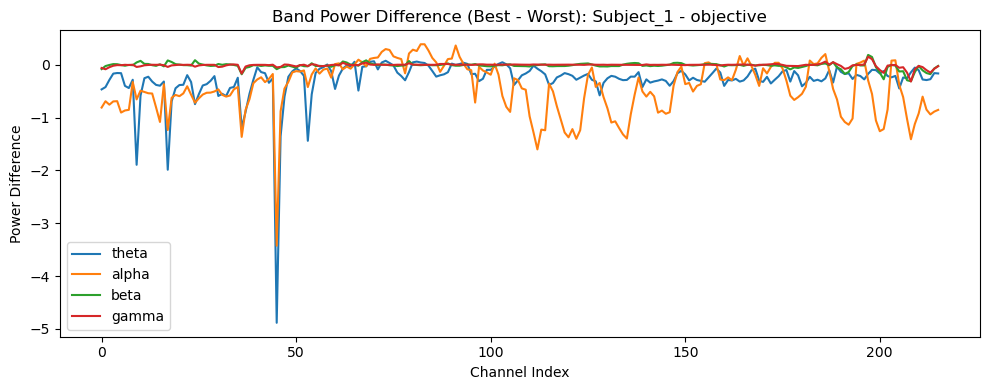

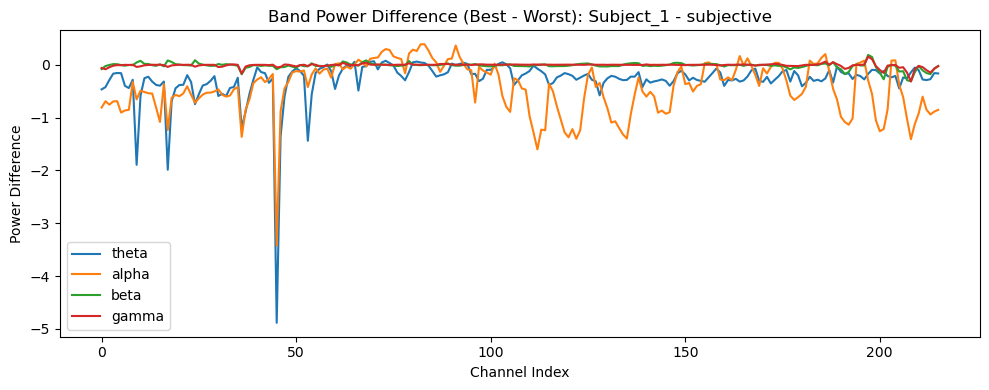

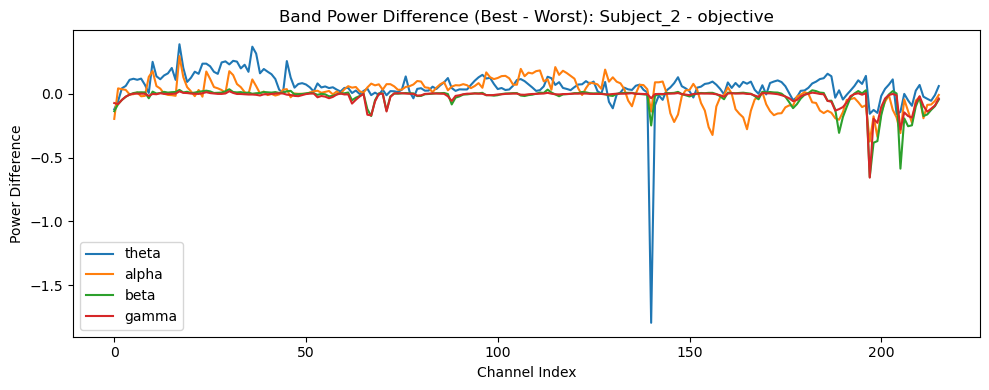

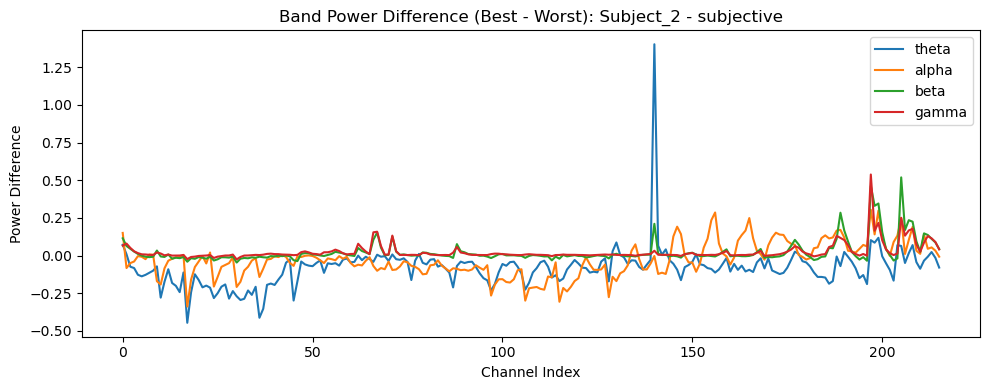

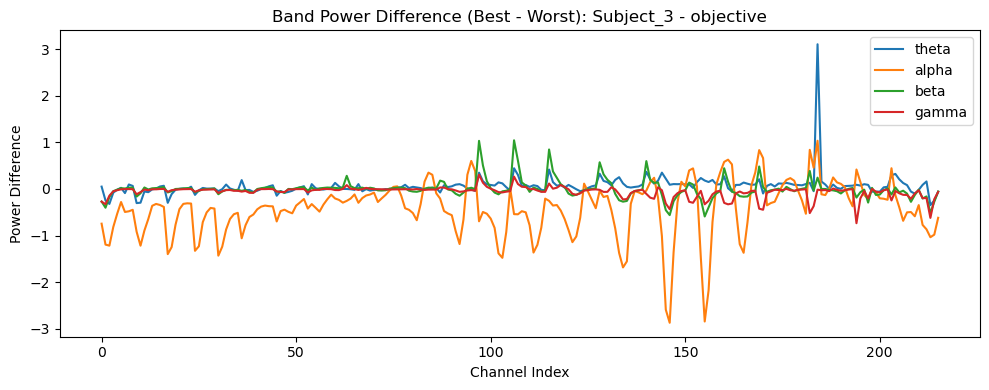

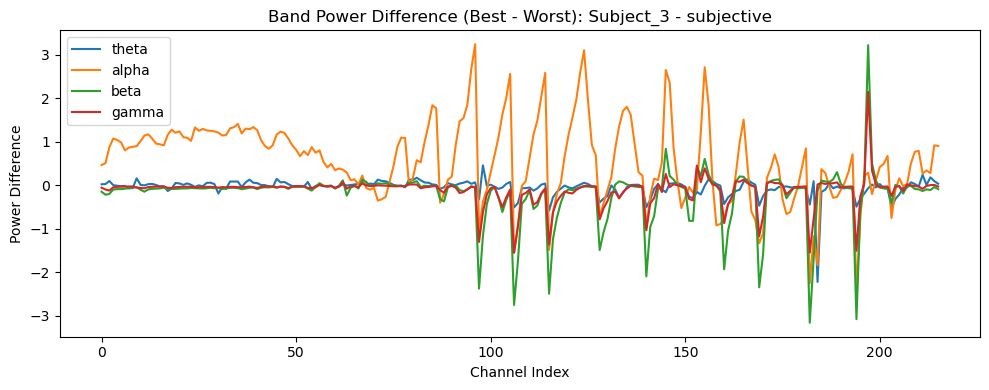

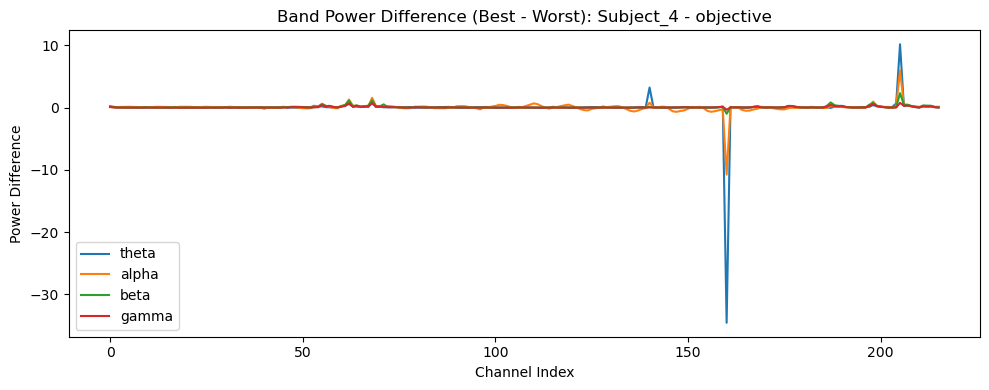

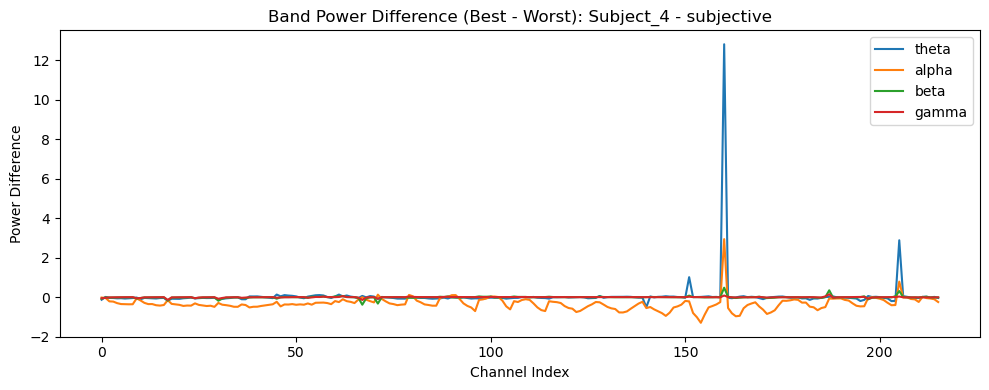

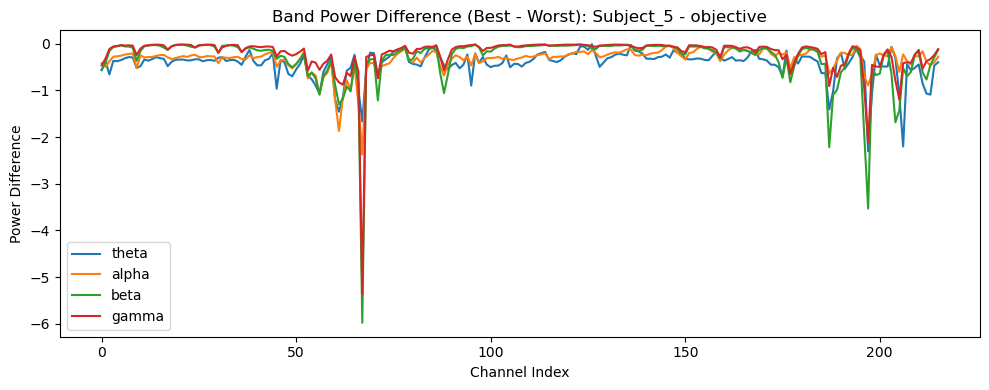

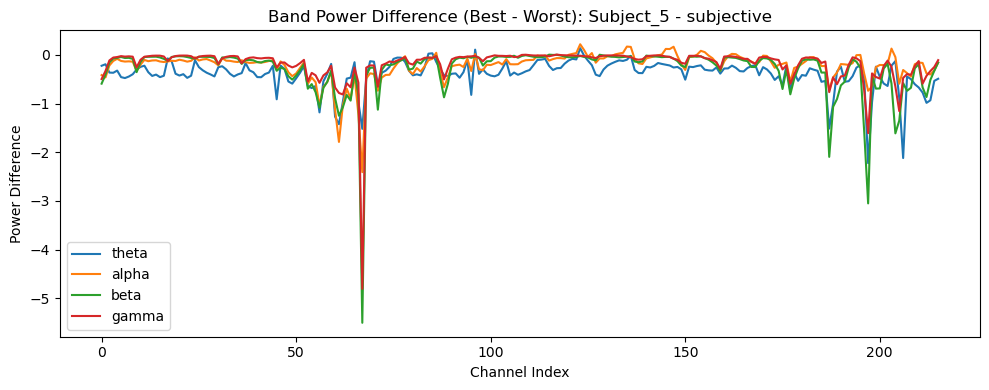

In [19]:
def compute_band_power(X, sfreq=250):
    """
    Compute power in each EEG frequency band for all channels and trials.
    
    Parameters:
        X (ndarray): EEG data (time_samples x channels x trials)
        sfreq (float): Sampling frequency in Hz (default: 250)
    
    Returns:
        dict: Band names mapped to power arrays (channels x trials)
    """
    n_channels = X.shape[1]
    n_trials = X.shape[2]
    band_powers = {band: np.zeros((n_channels, n_trials)) for band in eeg_bands}

    for i in range(n_trials):
        for ch in range(n_channels):
            f, psd = welch(X[:, ch, i], sfreq, nperseg=128)
            for band, (low, high) in eeg_bands.items():
                band_mask = (f >= low) & (f <= high)
                band_powers[band][ch, i] = np.mean(psd[band_mask])
    return band_powers

def average_band_diff(X_best, X_worst):
    """
    Compute difference in band power between best and worst odor trials.
    
    Parameters:
        X_best (ndarray): EEG data for pleasant/best-rated odors (time x channels x trials)
        X_worst (ndarray): EEG data for unpleasant/worst-rated odors (time x channels x trials)
    
    Returns:
        dict: Band names mapped to difference arrays per channel (average across trials)
    """
    power_best = compute_band_power(X_best)
    power_worst = compute_band_power(X_worst)

    band_diffs = {}
    for band in eeg_bands:
        mean_best = np.mean(power_best[band], axis=1)  # avg over trials
        mean_worst = np.mean(power_worst[band], axis=1)
        band_diffs[band] = mean_best - mean_worst
    return band_diffs

def plot_band_diffs(band_diffs, title, save_path=None):
    """
    Plot power difference across channels for each frequency band.
    
    Parameters:
        band_diffs (dict): Band names mapped to difference arrays per channel
        title (str): Title for the plot
        save_path (str): Optional path to save the figure
    """
    plt.figure(figsize=(10, 4))
    for i, (band, diff) in enumerate(band_diffs.items()):
        plt.plot(diff, label=band)
    plt.title(f'Band Power Difference (Best - Worst): {title}')
    plt.xlabel('Channel Index')
    plt.ylabel('Power Difference')
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


for subject in eeg_cleaned_dataset:
    for label_type in ['objective', 'subjective']:
        best_odors = []
        worst_odors = []

        for cond in ['eyes_open', 'eyes_closed']:
            best = best_worst_map[subject][cond]['best'] if label_type == 'subjective' else (4 if cond == 'eyes_open' else 2)
            worst = best_worst_map[subject][cond]['worst'] if label_type == 'subjective' else (3 if cond == 'eyes_open' else 1)

            best_X = eeg_cleaned_dataset[subject][cond].get(f'odor_{best}')
            worst_X = eeg_cleaned_dataset[subject][cond].get(f'odor_{worst}')
            if best_X is not None and worst_X is not None:
                best_odors.append(best_X)
                worst_odors.append(worst_X)

        if best_odors and worst_odors:
            X_best = np.concatenate(best_odors, axis=2)
            X_worst = np.concatenate(worst_odors, axis=2)
            band_diffs = average_band_diff(X_best, X_worst)
            subject_clean = subject.replace('_', '')
            plot_band_diffs(band_diffs, title=f"{subject} - {label_type}", 
                          save_path=f"../outputs/figures/band_diffs_{subject_clean}_{label_type}.png")

## 9. TOPOGRAPHICAL VISUALIZATION 



/var/folders/t5/gyg6dwcs2pg0sgvyb3_npn5h0000gn/T/ipykernel_82700/2984061902.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.93, 0.95])


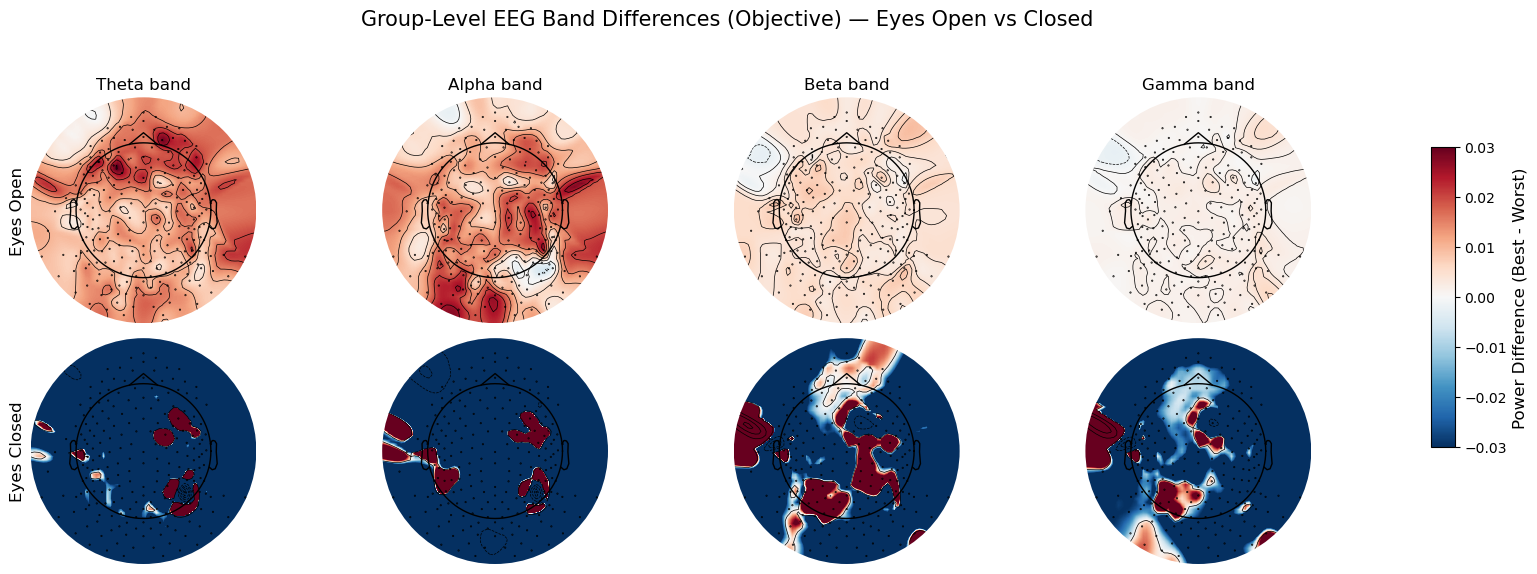

In [20]:
montage = mne.channels.make_standard_montage('GSN-HydroCel-256')
ch_names = montage.ch_names[:216]
ch_pos = {ch: pos[:3] for ch, pos in montage.get_positions()['ch_pos'].items() if ch in ch_names}


info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')
info.set_montage(montage)

all_band_maps = {'eyes_open': {}, 'eyes_closed': {}}

for cond in ['eyes_open', 'eyes_closed']:
    group_band_diffs = {band: [] for band in eeg_bands}

    for subject in eeg_cleaned_dataset:

        best = 4 if cond == 'eyes_open' else 2
        worst = 3 if cond == 'eyes_open' else 1

        best_X = eeg_cleaned_dataset[subject][cond].get(f'odor_{best}')
        worst_X = eeg_cleaned_dataset[subject][cond].get(f'odor_{worst}')

        if best_X is not None and worst_X is not None:
            band_best = compute_band_power(best_X)
            band_worst = compute_band_power(worst_X)

            for band in eeg_bands:
                mean_best = np.mean(band_best[band], axis=1)
                mean_worst = np.mean(band_worst[band], axis=1)
                diff = mean_best - mean_worst
                group_band_diffs[band].append(diff)

    avg_band_maps = {
        band: np.mean(group_band_diffs[band], axis=0) for band in eeg_bands
    }
    all_band_maps[cond] = avg_band_maps


fig, axes = plt.subplots(2, 4, figsize=(16, 6))
bands = ['theta', 'alpha', 'beta', 'gamma']
conditions = ['eyes_open', 'eyes_closed']

vlim_fixed = 0.03  

for row_idx, cond in enumerate(conditions):
    for col_idx, band in enumerate(bands):
        ax = axes[row_idx, col_idx]
        data = all_band_maps[cond][band]

        im, _ = plot_topomap(
            data,
            pos=info,
            axes=ax,
            show=False,
            cmap='RdBu_r',
            vlim=(-vlim_fixed, vlim_fixed),
            contours=6,
            sphere=0.07,
        )

        if row_idx == 0:
            ax.set_title(f'{band.capitalize()} band', fontsize=12)
        if col_idx == 0:
            ax.set_ylabel('Eyes Open' if cond == 'eyes_open' else 'Eyes Closed', fontsize=12)


fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.25, 0.015, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Power Difference (Best - Worst)', fontsize=12)

fig.suptitle('Group-Level EEG Band Differences (Objective) — Eyes Open vs Closed', fontsize=15)
plt.tight_layout(rect=[0, 0.03, 0.93, 0.95])
plt.savefig("../outputs/figures/topographical_band_differences.png", bbox_inches="tight")
plt.show()

### Results 3 — EEG Band Differences (Objective Labels)

We analyzed group-level EEG power differences between pleasant ("best") and unpleasant ("worst") odors across frequency bands (theta, alpha, beta, gamma), comparing eyes open and eyes closed conditions.

#### Eyes Open Condition

In the eyes open condition, pleasant odors were associated with increased power (red regions) across multiple frequency bands.

- **Theta band** showed widespread increases, particularly in frontal and parietal regions, suggesting enhanced attentional and emotional engagement.
- **Alpha band** also exhibited strong increases, mainly over centro-parietal areas, which may reflect processing related to reward or reduced cognitive load.
- **Beta band** showed moderate increases, especially in temporal-parietal regions.
- **Gamma band** differences were weaker and more diffuse.

Overall, these results suggest that pleasant odors, when combined with visual input, are associated with broad neural activation patterns, particularly in lower frequency bands.

#### Eyes Closed Condition

In contrast, the eyes closed condition showed predominantly negative differences (blue regions), indicating higher power for unpleasant odors.

- Unpleasant odors elicited stronger neural responses when visual input was absent.
- Activation patterns were more localized compared to the eyes open condition.
- **Beta and gamma bands** showed more focal increases, particularly in temporal regions.
- These patterns may reflect increased sensory processing, odor intensity encoding, or familiarity-related mechanisms.



#### General Interpretation

Across conditions, the results suggest that sensory context (eyes open vs. closed) significantly modulates EEG responses to odor pleasantness.

- With eyes open, responses are more global and associated with attention and valence processing.
- With eyes closed, responses become more localized and may reflect deeper internal or sensory-driven processing.

These findings highlight the importance of multisensory context in shaping neural representations of odor perception.

## 10. MACHINE LEARNING 


In [21]:
X_list = []
y_list = []

feature_names = []
for band in eeg_bands:
    for ch in range(216):
        feature_names.append(f"ch{ch}_{band}")

pleasant_odors = [2, 4]
unpleasant_odors = [1, 3]


for subject in eeg_cleaned_dataset:
    cond = 'eyes_open'
    
    for odor in pleasant_odors:
        X_pleasant = eeg_cleaned_dataset[subject][cond].get(f'odor_{odor}')
        if X_pleasant is not None:
            for i in range(X_pleasant.shape[2]):
                bp = compute_band_power(X_pleasant[:, :, i:i+1])
                features = []
                for band in eeg_bands:
                    features.extend(bp[band][:, 0])
                X_list.append(features)
                y_list.append(1)

    for odor in unpleasant_odors:
        X_unpleasant = eeg_cleaned_dataset[subject][cond].get(f'odor_{odor}')
        if X_unpleasant is not None:
            for i in range(X_unpleasant.shape[2]):
                bp = compute_band_power(X_unpleasant[:, :, i:i+1])
                features = []
                for band in eeg_bands:
                    features.extend(bp[band][:, 0])
                X_list.append(features)
                y_list.append(0)




/Users/clarahautemaniere/miniconda3/envs/Odor_pleasantness/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [13:43:18] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1772125028439/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


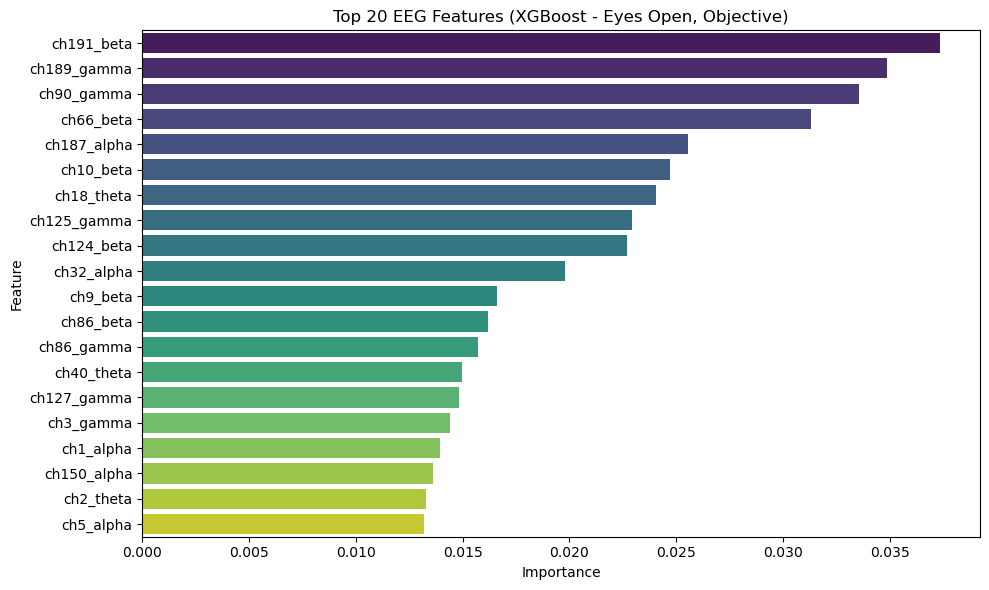

In [22]:
X = np.array(X_list)
y = np.array(y_list)


model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model.fit(X, y)

# Plot top 20 most important features
importances = model.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

top_features = pd.DataFrame({
    "Feature": [feature_names[i] for i in top_idx],
    "Importance": importances[top_idx]
})

# Save feature importance results
top_features.to_csv("../outputs/results/feature_importance_xgboost.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature", palette="viridis")
plt.title("Top 20 EEG Features (XGBoost - Eyes Open, Objective)")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance_xgboost.png", bbox_inches="tight")
plt.show()


### Results 4 — Feature Importance (XGBoost, Eyes Open, Objective Labels)

We examined the most important EEG features identified by the XGBoost model in the eyes open condition using objective pleasantness labels.

#### 1- Dominance of the Beta Band

The beta band was the most important frequency range, with 10 out of the top 20 features belonging to this band (e.g., ch9_beta, ch74_beta, ch42_beta, ch211_beta).

This suggests that beta activity plays a major role in distinguishing between pleasant and unpleasant odors, and may reflect processes related to attention and sensorimotor activity.

#### 2- Frontal and Central Channel Involvement

Many of the important features were located in frontal and central channels, such as ch2, ch13, ch42, and ch74.

This indicates that the model relies on activity in frontal-central regions, which are often linked to emotional and cognitive processing.

#### 3- Contribution of Alpha and Theta Bands

Alpha and theta bands also contributed to the model, although less than beta.

Some of these features (e.g., ch2_alpha, ch13_alpha, ch126_theta, ch103_theta) appeared among the top predictors.

This suggests that these bands may also be involved in odor perception, possibly related to valence and attentional processes.

#### 4- Limited Role of Gamma Band

A small number of gamma features were present (4 features), but they were less dominant compared to other bands.

This indicates a more limited contribution of gamma activity in the model.


In [23]:
# Create a dictionary to store feature importance for each EEG frequency band
band_values = {band: np.zeros(216) for band in eeg_bands.keys()}

for feat, imp in zip(feature_names, importances):
    ch_str, band = feat.split("_")
    ch_idx = int(ch_str.replace("ch", ""))
    band_values[band][ch_idx] = imp

/var/folders/t5/gyg6dwcs2pg0sgvyb3_npn5h0000gn/T/ipykernel_82700/3068277558.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.95])


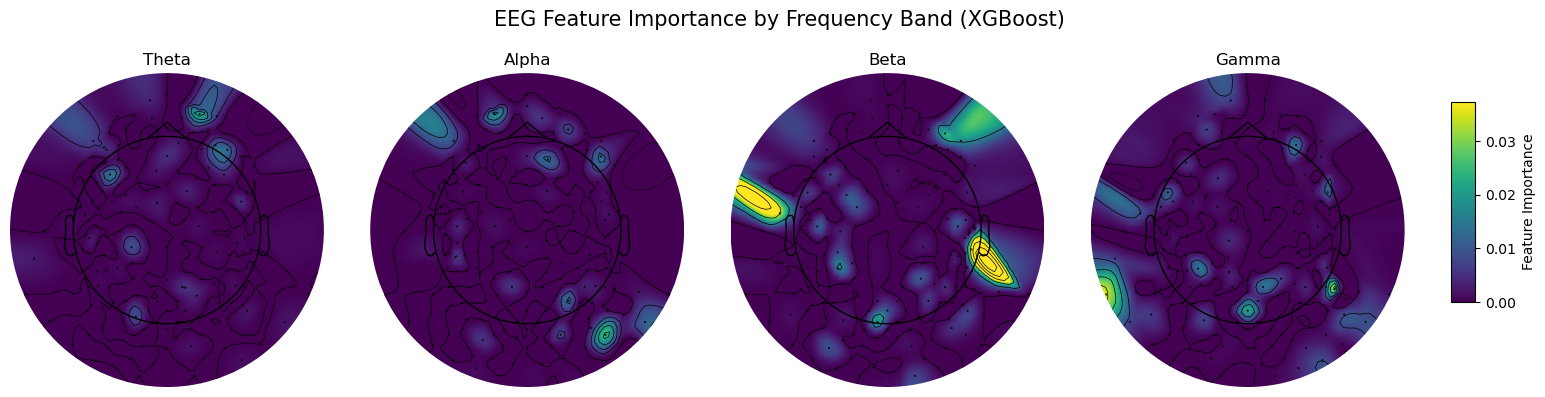

In [24]:
# Plot topographical maps of feature importance for each frequency band
band_values = {band: np.zeros(216) for band in eeg_bands.keys()}

for feat, imp in zip(feature_names, importances):
    ch_str, band = feat.split("_")
    ch_idx = int(ch_str.replace("ch", ""))
    band_values[band][ch_idx] = imp

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
bands = ['theta', 'alpha', 'beta', 'gamma']
vlim_max = max(np.max(np.abs(v)) for v in band_values.values())

for i, band in enumerate(bands):
    ax = axes[i]
    plot_topomap(
        band_values[band],
        pos=info,
        axes=ax,
        cmap='viridis',
        contours=6,
        sphere=0.07,
        vlim=(0, vlim_max),
        show=False
    )
    ax.set_title(f"{band.capitalize()}", fontsize=12)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
norm = plt.Normalize(vmin=0, vmax=vlim_max)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Feature Importance')

fig.suptitle("EEG Feature Importance by Frequency Band (XGBoost)", fontsize=15)
plt.tight_layout(rect=[0, 0, 0.91, 0.95])
plt.savefig("../outputs/figures/feature_importance_topomap.png", bbox_inches="tight")
plt.show()

### Results 5 — Spatial Distribution of Feature Importance (XGBoost)

We visualized where the most important EEG features are located across frequency bands.

#### Beta and Alpha Bands

Beta and alpha bands show the strongest importance, mainly in frontal, central, and parietal regions.

This suggests that these bands and brain areas are key for predicting odor pleasantness.

#### Theta and Gamma Bands

Theta and gamma bands also contribute, but to a lesser extent.

Their role appears more subtle, although still meaningful for the model.

## 11. ADDITIONAL STATISTICAL ANALYSIS 

In [25]:
beta_band = (13, 30)
pleasant_odors = [2, 4]
unpleasant_odors = [1, 3]

def compute_beta_power(X, sfreq=250):
    """
    Compute beta band (13-30 Hz) power for all channels and trials.
    
    Parameters:
        X (ndarray): EEG data (time_samples x channels x trials)
        sfreq (float): Sampling frequency in Hz (default: 250)
    
    Returns:
        ndarray: Beta power per channel and trial (channels x trials)
    """
    n_channels = X.shape[1]
    n_trials = X.shape[2]
    power = np.zeros((n_channels, n_trials))
    for i in range(n_trials):
        for ch in range(n_channels):
            f, psd = welch(X[:, ch, i], fs=sfreq, nperseg=128)
            mask = (f >= beta_band[0]) & (f <= beta_band[1])
            power[ch, i] = np.mean(psd[mask])
    return power

def get_channel_positions(info):
    """
    Extract 3D coordinates and labels for all EEG channels from MNE info.
    
    Parameters:
        info (mne.Info): MNE Info object containing channel information
    
    Returns:
        tuple: (xyz coordinates array, channel labels list)
    """
    xyz = np.array([ch['loc'][:3] for ch in info['chs']])
    labels = [ch['ch_name'] for ch in info['chs']]
    return xyz, labels

def plot_3d_scalp_map(values, info, title="3D Scalp Map", save_path=None):
    """
    Create interactive 3D scalp map using Plotly.
    
    Parameters:
        values (ndarray): Values to plot on channels (e.g., t-statistics, power differences)
        info (mne.Info): MNE Info object with channel positions
        title (str): Title for the plot
        save_path (str): Optional path to save the figure as HTML
    """
    xyz, labels = get_channel_positions(info)
    fig = go.Figure(data=[
        go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='markers+text',
            marker=dict(
                size=6,
                color=values,
                colorscale='RdBu',
                colorbar=dict(title='T-value'),
                showscale=True,
                opacity=0.9
            ),
            text=labels,
            hoverinfo='text'
        )
    ])
    fig.update_layout(
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode='data'
        ),
        title=title,
        margin=dict(l=0, r=0, t=40, b=0)
    )
    if save_path:
        fig.write_html(save_path)
    fig.show()


for subject in eeg_cleaned_dataset:
    data = eeg_cleaned_dataset[subject]['eyes_open']

    pleasant = [data[f'odor_{i}'] for i in pleasant_odors if f'odor_{i}' in data]
    unpleasant = [data[f'odor_{i}'] for i in unpleasant_odors if f'odor_{i}' in data]
    if not pleasant or not unpleasant:
        continue

    X_pleasant = np.concatenate(pleasant, axis=2)
    X_unpleasant = np.concatenate(unpleasant, axis=2)

    power_pleasant = compute_beta_power(X_pleasant)
    power_unpleasant = compute_beta_power(X_unpleasant)

    t_vals, p_vals = stats.ttest_ind(power_pleasant, power_unpleasant, axis=1, equal_var=False)

    subject_clean = subject.replace('_', '')
    plot_3d_scalp_map(t_vals, info, title=f"{subject} — Beta T-values (Pleasant vs Unpleasant, Eyes Open)",
                     save_path=f"../outputs/figures/scalp_map_beta_tvals_{subject_clean}.html")

### Results 6 — Beta Band Differences (Subjective Labels)

We computed t-values for each EEG channel to compare beta-band power between pleasant and unpleasant odors.

Positive t-values indicate stronger activity for pleasant odors, while negative t-values indicate stronger activity for unpleasant odors.

The results show clear differences between conditions, suggesting that beta activity varies depending on subjective odor perception.

## 8. FUTURE DIRECTIONS: Applications & Extensions

### Future Directions — Applications and Extensions

The results suggest several possible applications and future research directions.

#### 1. EEG-Based Personal Preference Prediction

One application is to predict whether a person will like a new fragrance based on their brain activity.

Models could be used to predict pleasantness for new odors and help create personalized scent recommendations. This could lead to tools like “smart scent testers” for marketing.

#### 2. Subject Clustering and Fragrance Profiling

Another idea is to group people based on their EEG responses to different odors.

This would help identify groups of individuals who react similarly to certain fragrance types (e.g., floral, spicy). These groups could then be used to better target products to specific users or populations.

#### 3. Odor Space Mapping from EEG

Future work could create maps of odors based on brain responses instead of subjective ratings.

Methods like t-SNE or multidimensional scaling could be used to visualize how different odors relate to each other in terms of brain activity. This could help guide fragrance design.

#### 4. Neural Markers of “Signature” Scents

Some odors may not be rated as very pleasant but still produce strong brain responses.

These “signature” scents could be identified by looking at strong EEG changes and memory-related activity. This could help find fragrances that leave a lasting impression, even unconsciously.

#### 5. Dose–Response Effects

Another direction is to study how odor intensity affects brain responses.

For a given fragrance, it would be useful to find the level that maximizes effects like pleasure, calmness, or memorability. This could be tested by varying odor concentration and measuring EEG responses.

#### Overall

Overall, these directions show how EEG can be used to better understand and predict odor perception, with applications in research and industry.